In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_csv('Data/TEX.csv', parse_dates=['date_time'], na_values=['MISSING', 'EMPTY'])
df = df.set_index('date_time')

df.shape

# Print max and min values of the dates
print(f"Max date: {df.index.max()}")
print(f"Min date: {df.index.min()}")

print(df['cleaned demand (MW)'].describe())
print(df['cleaned demand (MW)'].isna().sum())

Max date: 2024-12-31 23:00:00
Min date: 2020-01-01 00:00:00
count    43848.000000
mean     48247.804643
std      10947.427884
min      27445.000000
25%      40373.750000
50%      45663.500000
75%      53990.250000
max      85559.000000
Name: cleaned demand (MW), dtype: float64
0


In [6]:
print(df.index.to_series().diff().value_counts()) 

date_time
0 days 01:00:00    43847
Name: count, dtype: int64


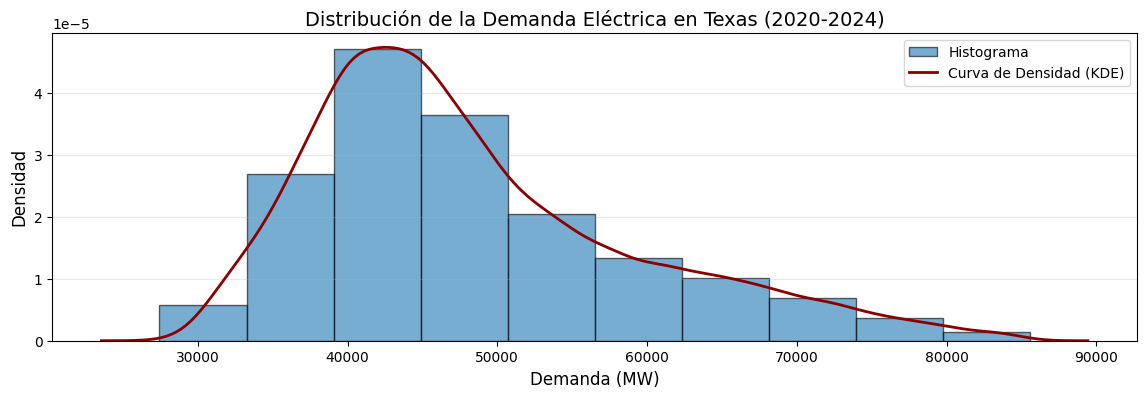

In [25]:
plt.figure(figsize=(14,4))

plt.hist(df['cleaned demand (MW)'], color='#1f77b4', edgecolor='black', density=True, alpha=0.6, label='Histograma')

sns.kdeplot(df['cleaned demand (MW)'], color='darkred', linewidth=2, label='Curva de Densidad (KDE)')

plt.title('Distribución de la Demanda Eléctrica en Texas (2020-2024)', fontsize=14)
plt.xlabel('Demanda (MW)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Analisis

El analisis de la demanda (KDE) muestra que la demanda tiene una distribucion Unimodal, con una moda alrededor de los 40,000 MW sesgada a la derecha por picos de verano y el invierno aporta poco a esa cola larga de forma sistematica, aparece mas como golpes ocacionales de frío (siendo una de ellos Uri). La demanda tiene una cola larga a la derecha, lo que indica que hay eventos de alta demanda que ocurren con menor frecuencia pero que pueden ser significativos. La demanda minima es de alrededor de 27,445 MW, mientras que la maxima puede superar los 85,559 MW durante eventos extremos.

# Cosas a considerar

- Desastre tormenta Uri en febrero 2021, con temperaturas extremadamente bajas que llevaron a un aumento significativo en la demanda de electricidad para calefacción, lo que resultó en apagones generalizados en Texas. Este evento destaca la importancia de considerar eventos climáticos extremos al analizar la demanda de electricidad y planificar la capacidad de generación y distribución.
Algo a tener en cuenta, en los datos se revela que a partir del 2021-02-09 se observa un aumento significativo en la demanda de electricidad, lo que coincide con el inicio de la tormenta de Uri, aunque tambiens e dice que hubieron apagones siendo que por eso despues del 2021-02-14 este disminuyera significativamente.

- COVID-19 en 2020: Hubo cambios al inicio de marzo donde se implementaron medidas de confinamiento que afectaron la demanda de electricidad, con una disminución en el consumo. 

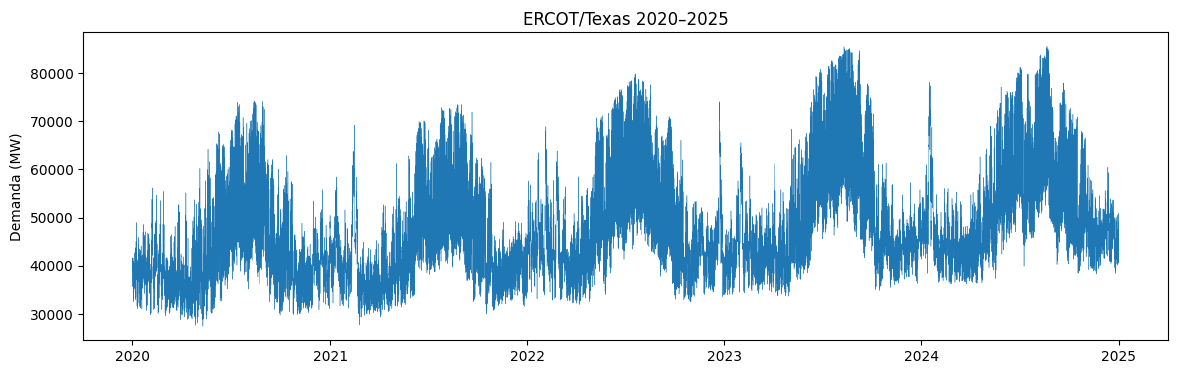

In [7]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['cleaned demand (MW)'], linewidth=0.3)
plt.ylabel('Demanda (MW)'); plt.title('ERCOT/Texas 2020–2025')
plt.show()

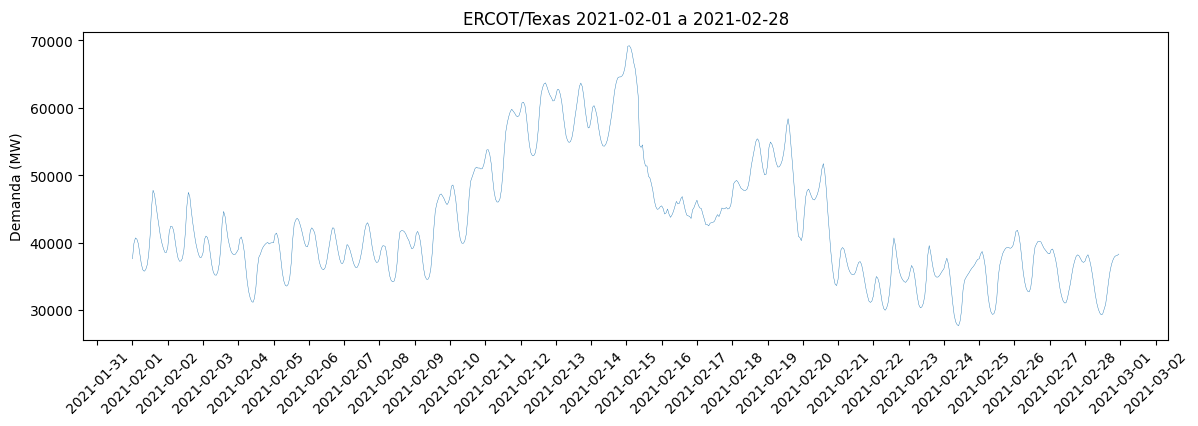

In [43]:

# Acercarse a las dos semanas con hora y todos los dias completos
sub = df.loc['2021-02-01':'2021-02-28', 'cleaned demand (MW)']
plt.figure(figsize=(14,4))
plt.plot(sub.index, sub.values, linewidth=0.3)
plt.ylabel('Demanda (MW)')
plt.title('ERCOT/Texas 2021-02-01 a 2021-02-28')

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()

# Ciclos Observados

- Promedio por hora del día: Se observa un patrón diario con picos de demanda durante las horas de la tarde y noche, y valles durante la madrugada.

- Promedio por día de la semana: Se observa un patrón semanal con picos durante los dias laborales y descensos durante los fines de semana.

- Promedio por mes: Se observa un patrón anual con picos durante los meses de verano (junio, julio y agosto) siendo agosto uno de los mas variados teniendo una mediana cerca de 60,000 MW y
descensos durante los meses de invierno (diciembre, enero y febrero). La diferencia entre el mes con mayor demanda (agosto) y el mes con menor demanda (marzo) es de aproximadamente 20,000 MW, lo que representa una variación significativa en la demanda a lo largo del año.

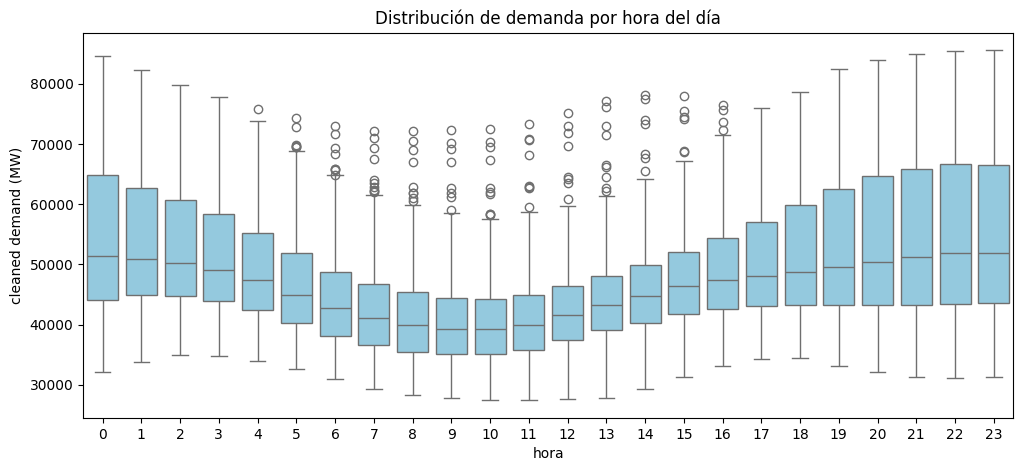

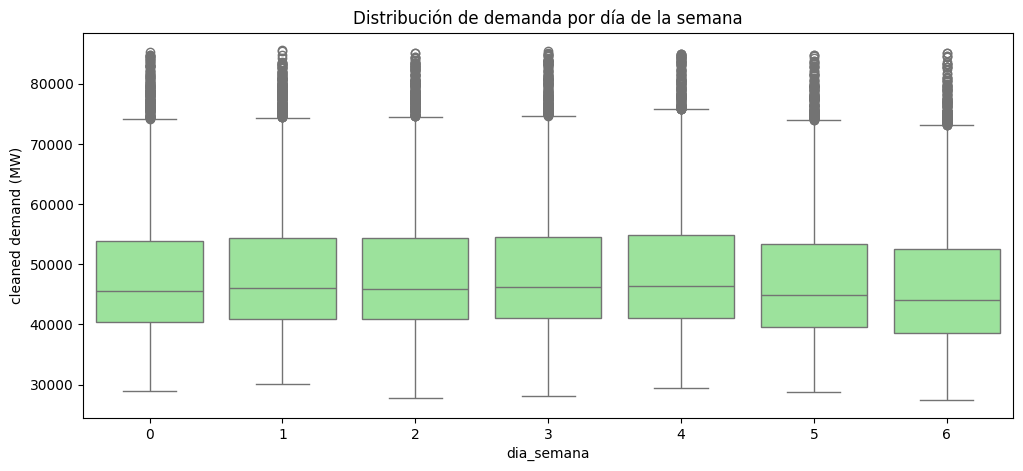

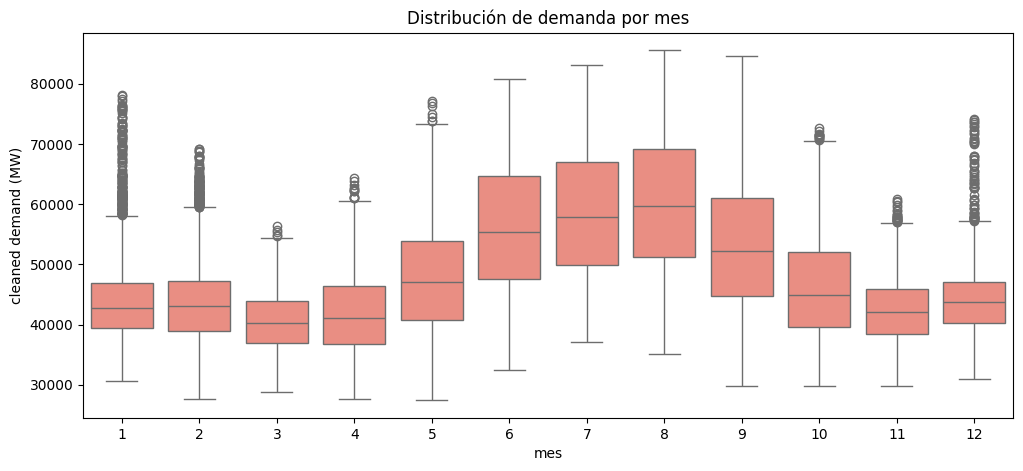

In [44]:
df['hora'] = df.index.hour
df['dia_semana'] = df.index.dayofweek
df['mes'] = df.index.month

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='hora', y='cleaned demand (MW)', color='skyblue')
plt.title('Distribución de demanda por hora del día')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='dia_semana', y='cleaned demand (MW)', color='lightgreen')
plt.title('Distribución de demanda por día de la semana')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='mes', y='cleaned demand (MW)', color='salmon')
plt.title('Distribución de demanda por mes')
plt.show()